Это pandas DataFrame!
Это pandas DataFrame!


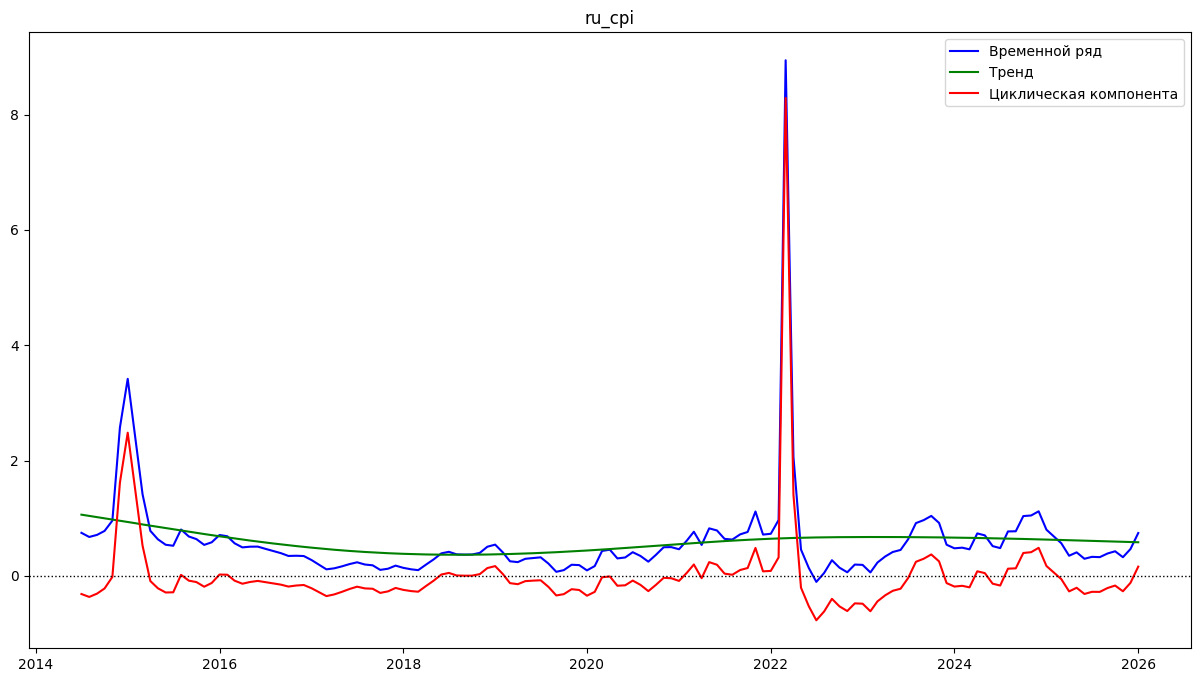

Исходный ряд ru_cpi оказался стационарным


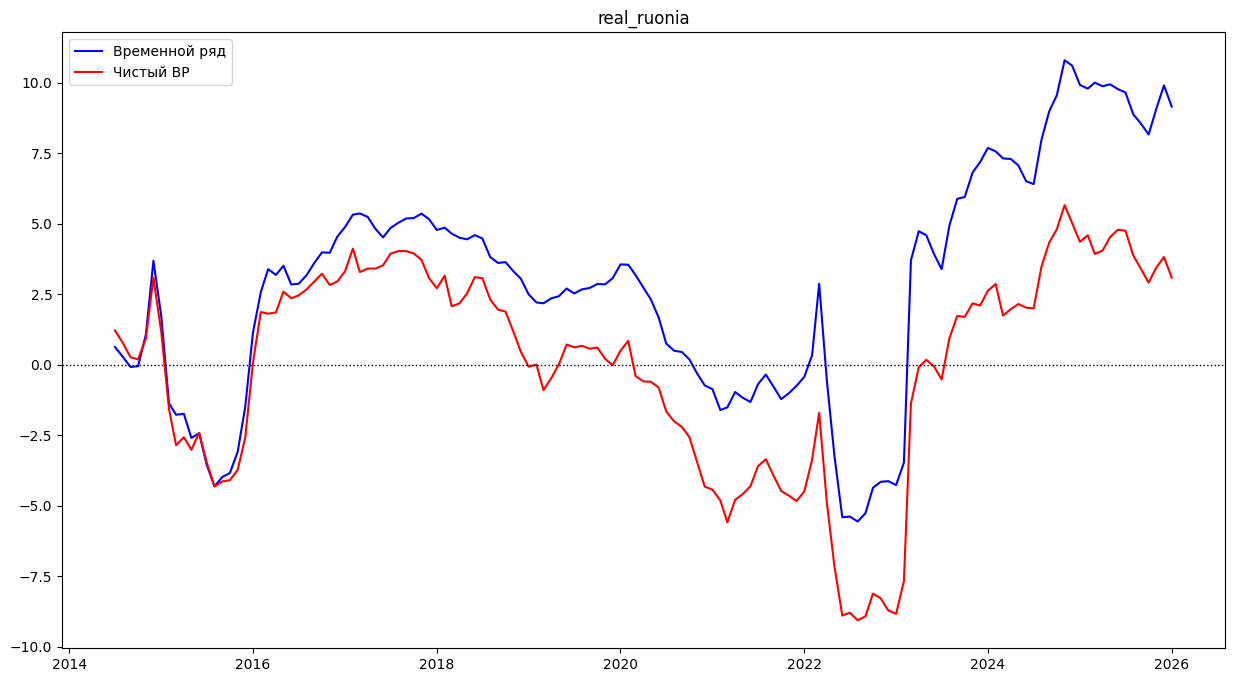

Исходный ряд real_ruonia оказался стационарным


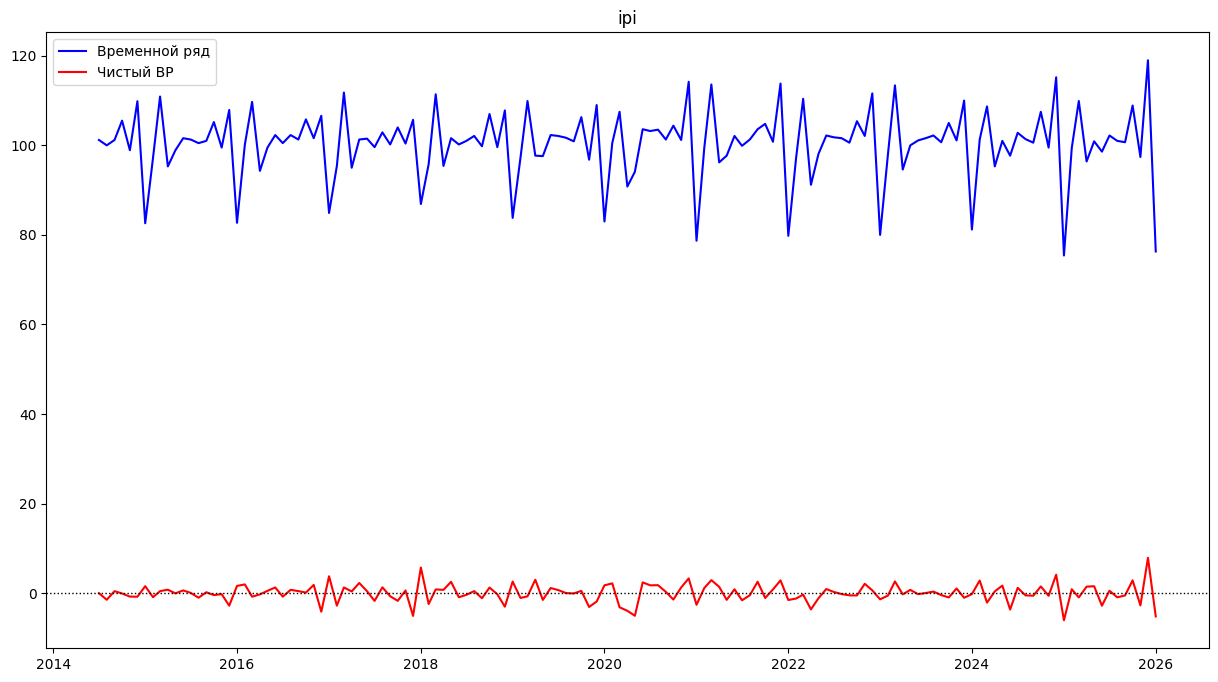

Исходный ряд ipi оказался стационарным


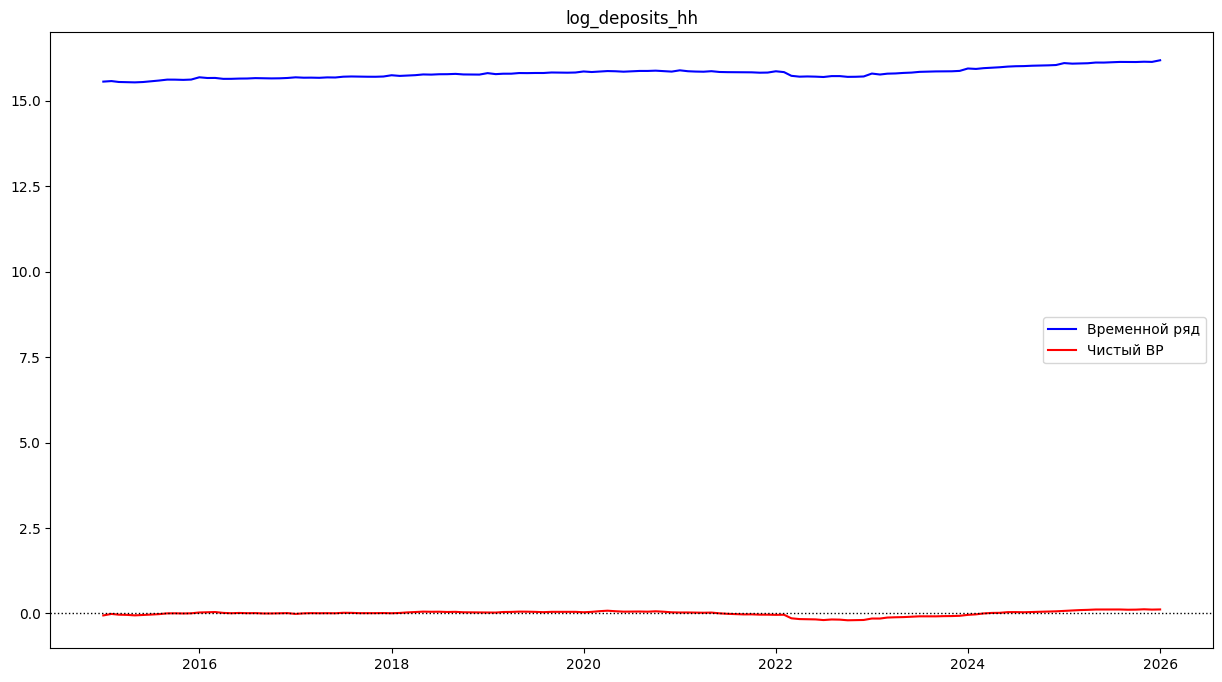

Исходный ряд log_deposits_hh оказался стационарным


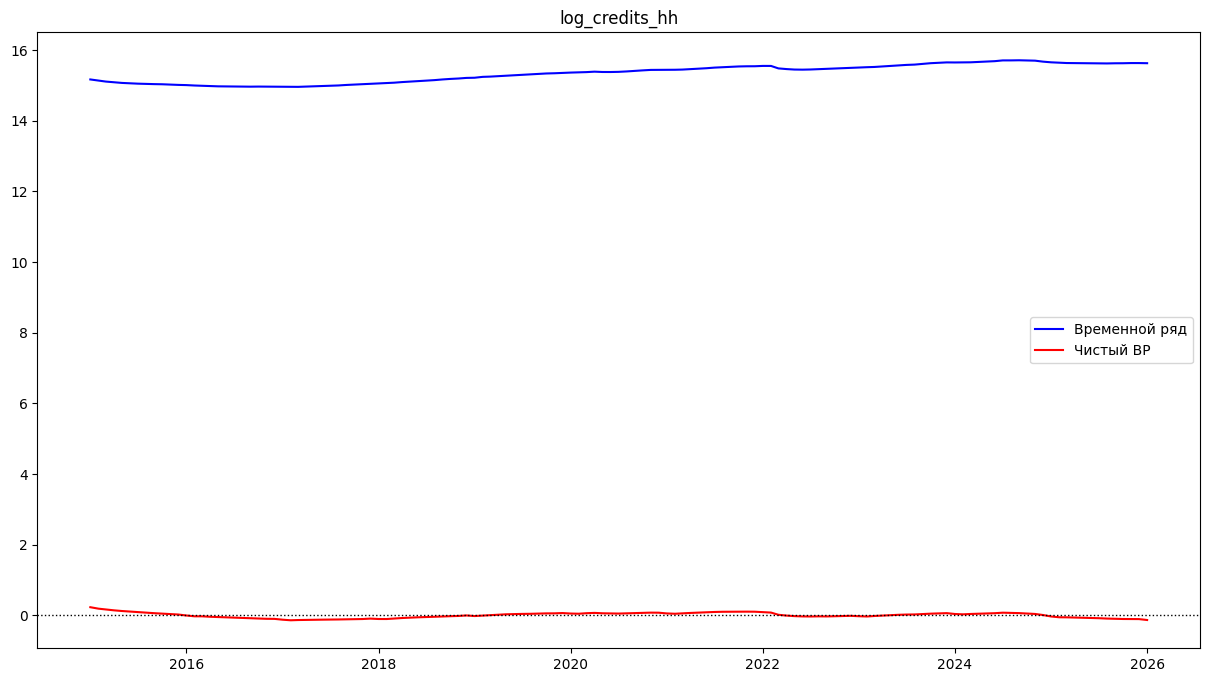

Исходный ряд log_credits_hh оказался стационарным


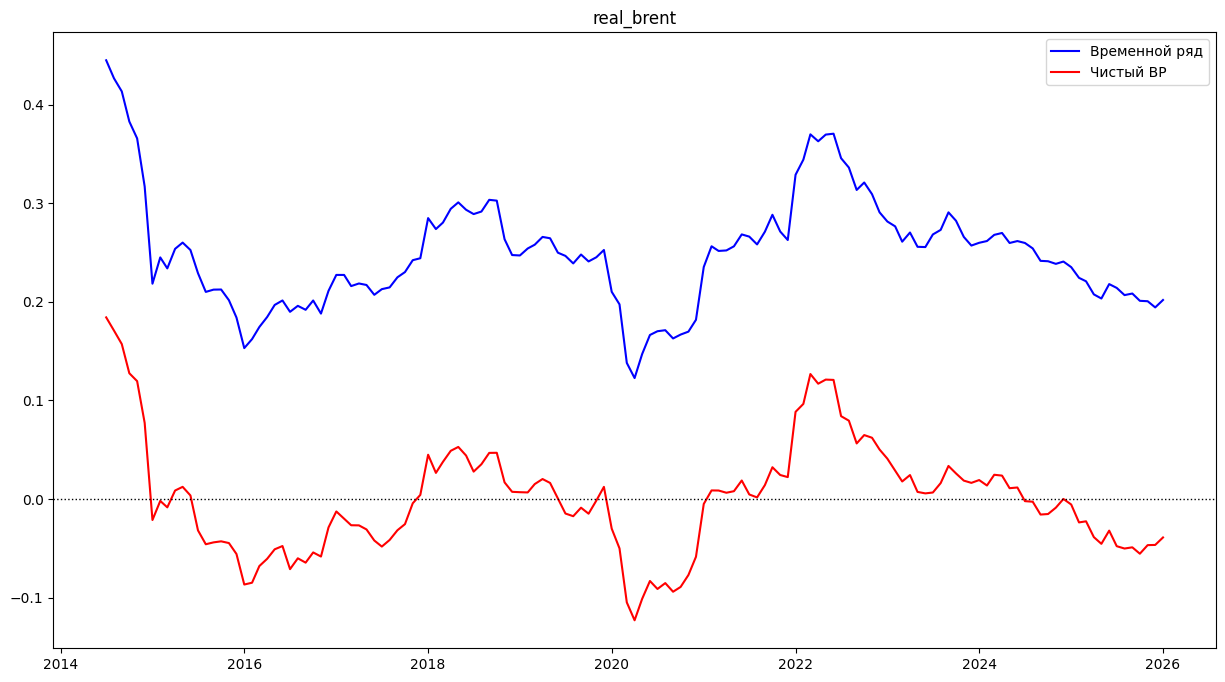

Исходный ряд real_brent оказался стационарным


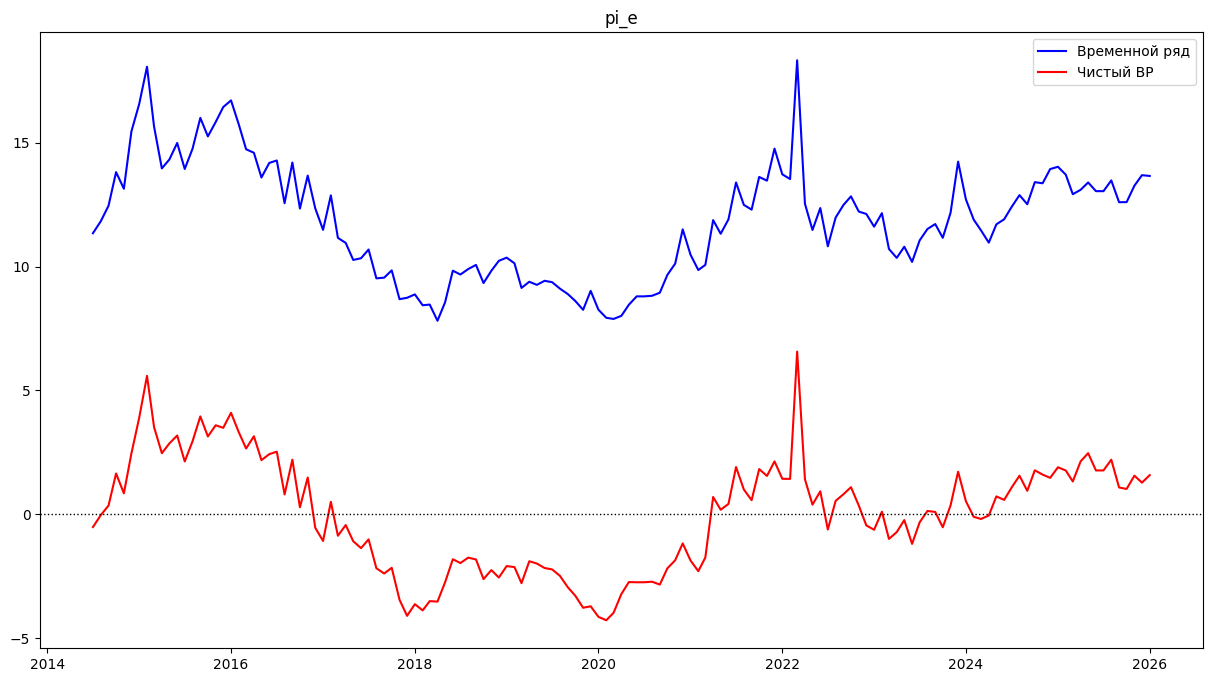

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


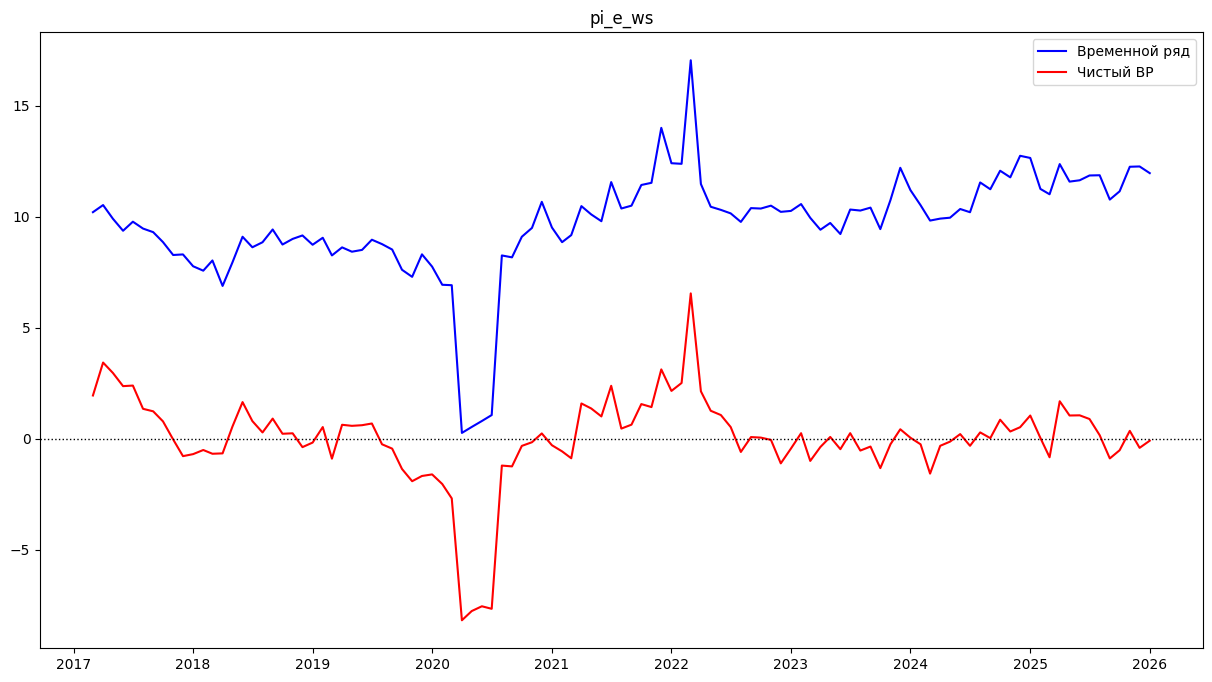

Исходный ряд pi_e_ws оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


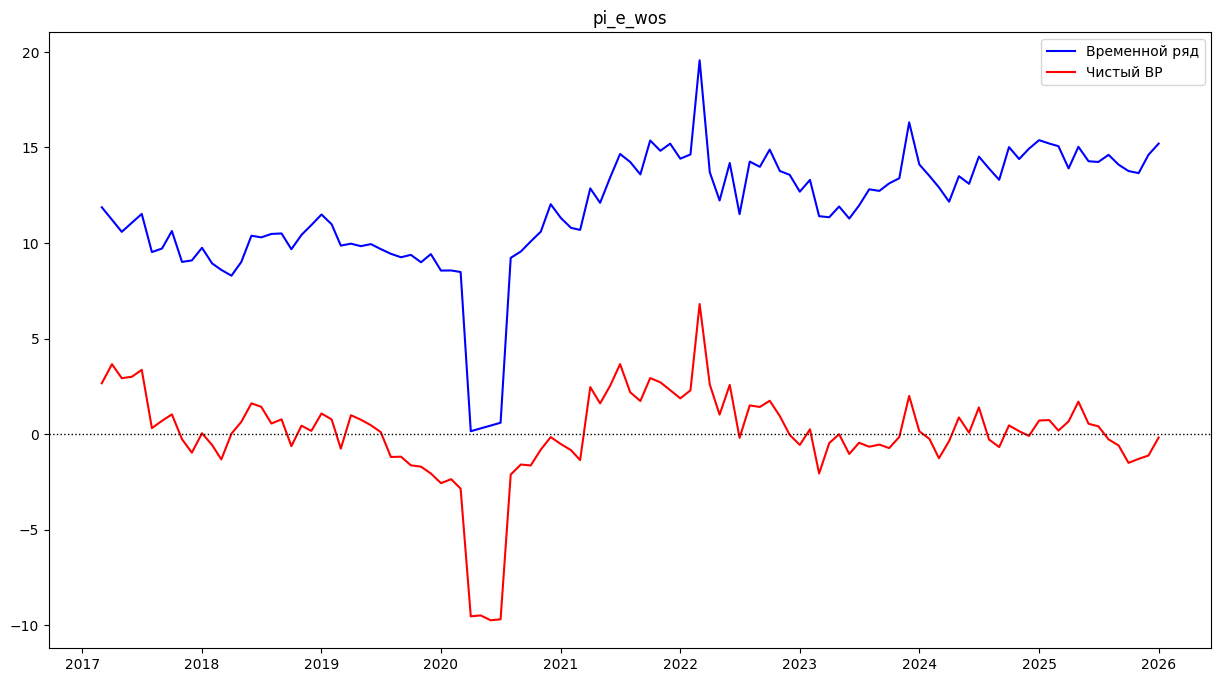

Исходный ряд pi_e_wos оказался стационарным


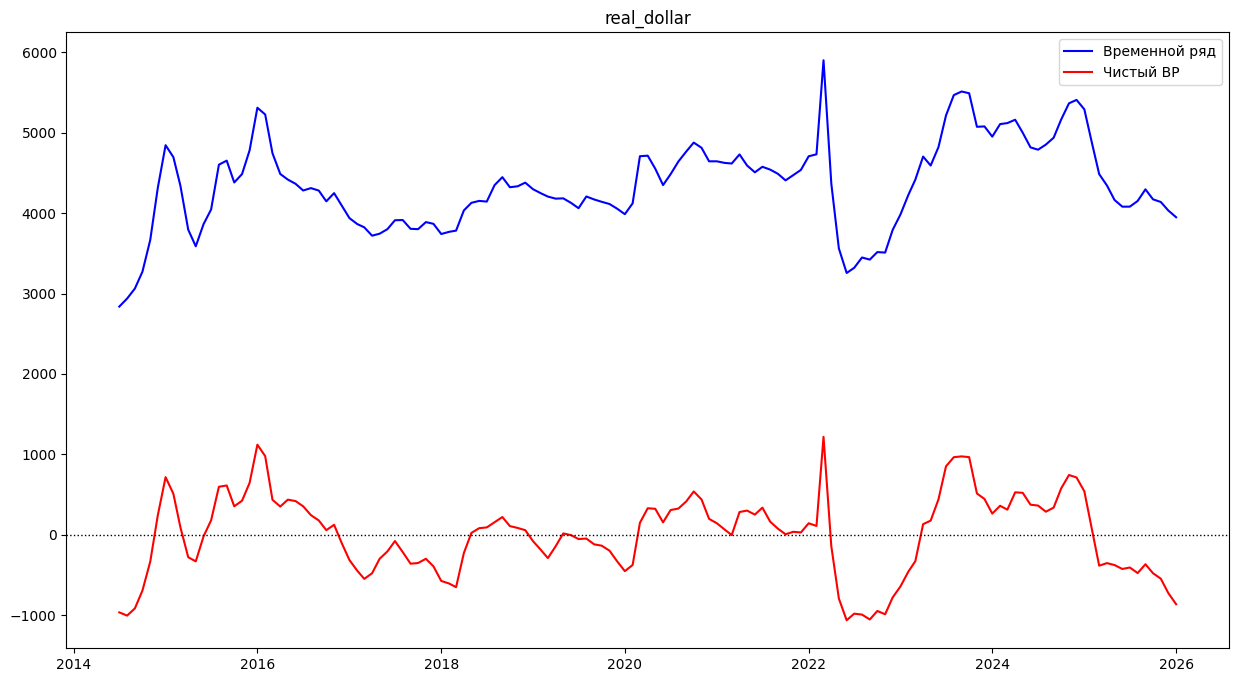

Исходный ряд real_dollar оказался стационарным


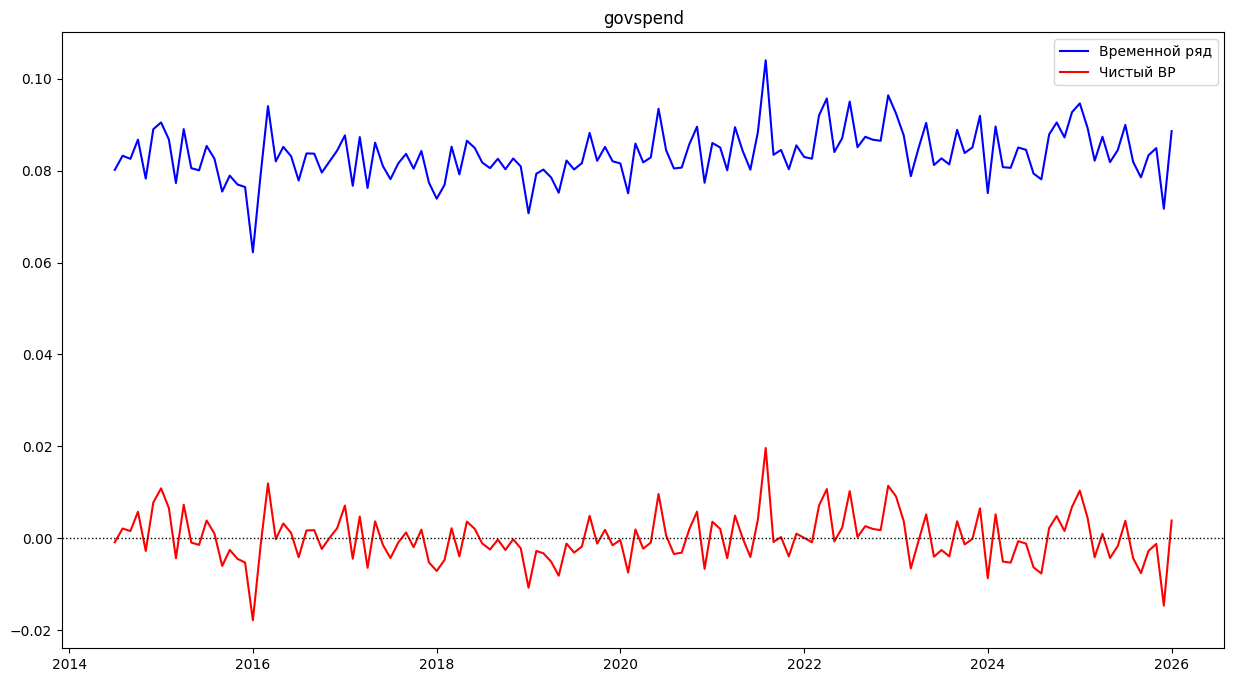

Исходный ряд govspend оказался стационарным


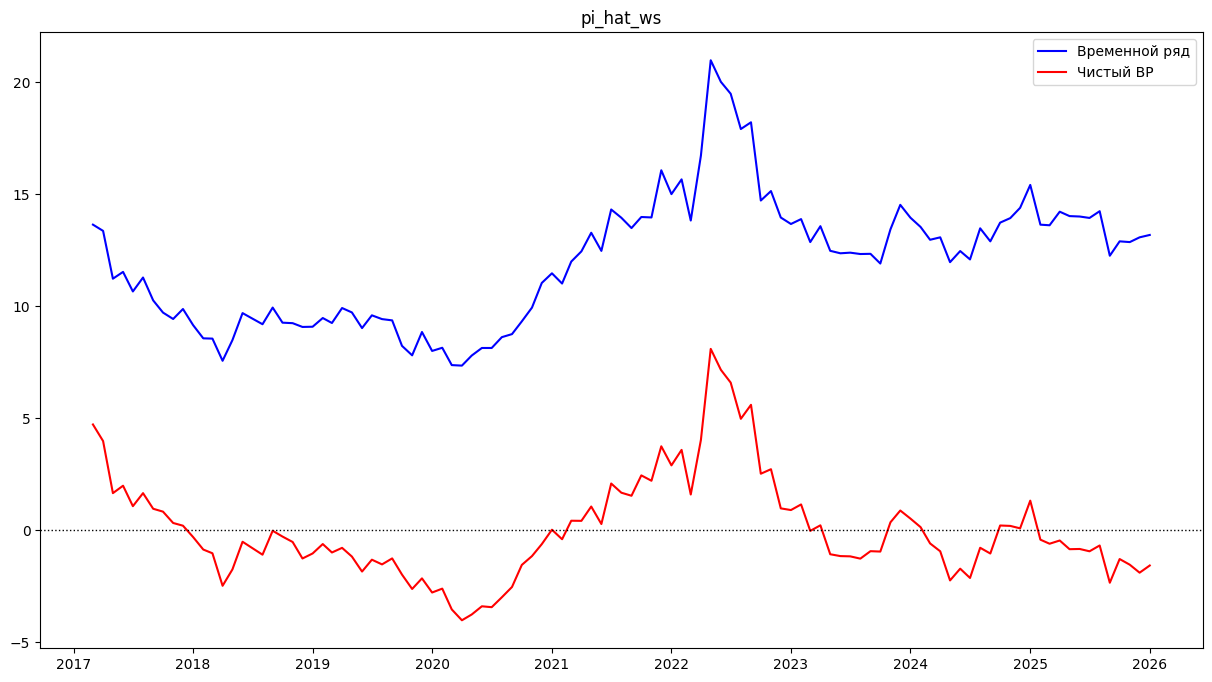

Исходный ряд pi_hat_ws оказался стационарным


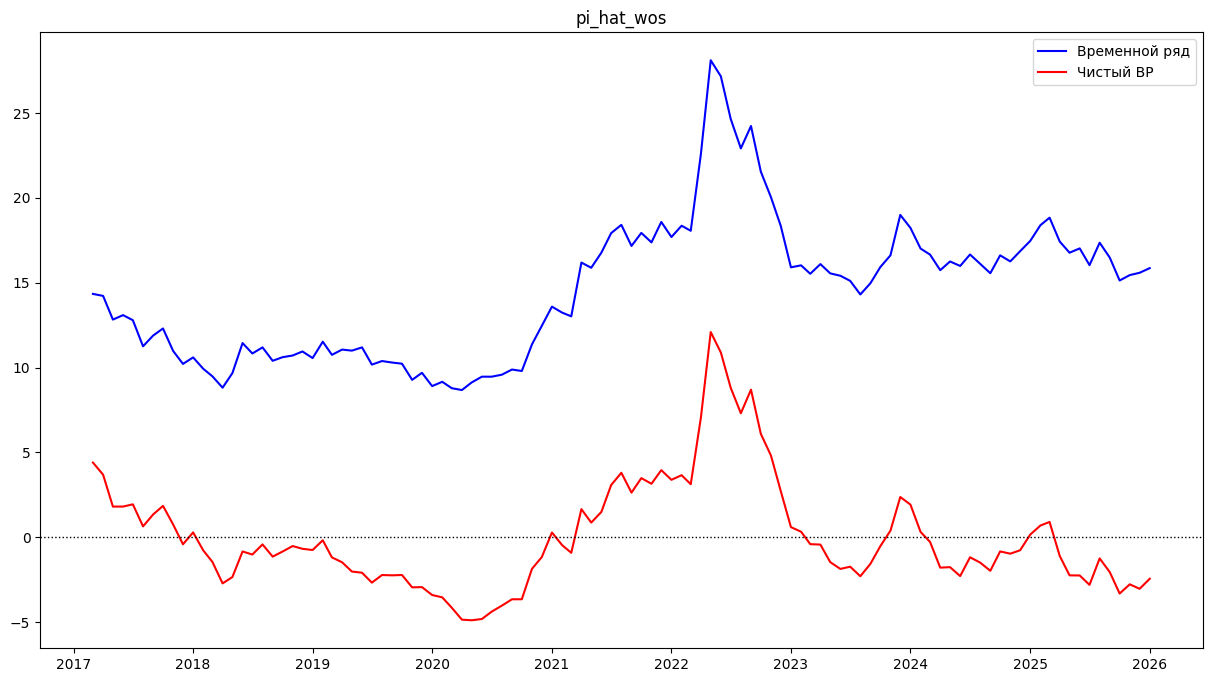

Исходный ряд pi_hat_wos оказался стационарным


C:\Users\vasil\YandexDisk\project\structuralvar\src\structuralvar\cleaning.py:577: RuntimeWarning: invalid value encountered in log
  aic = np.log(np.linalg.det(u)) + 2 / T * (lag * K**2 + K)
C:\Users\vasil\YandexDisk\project\structuralvar\src\structuralvar\cleaning.py:580: RuntimeWarning: invalid value encountered in log
  hqc = np.log(np.linalg.det(u)) + 2 * np.log(np.log(T)) / T * (lag * K**2 + K)
C:\Users\vasil\YandexDisk\project\structuralvar\src\structuralvar\cleaning.py:583: RuntimeWarning: invalid value encountered in log
  sic = np.log(np.linalg.det(u)) + np.log(T) / T * (lag * K**2 + K)


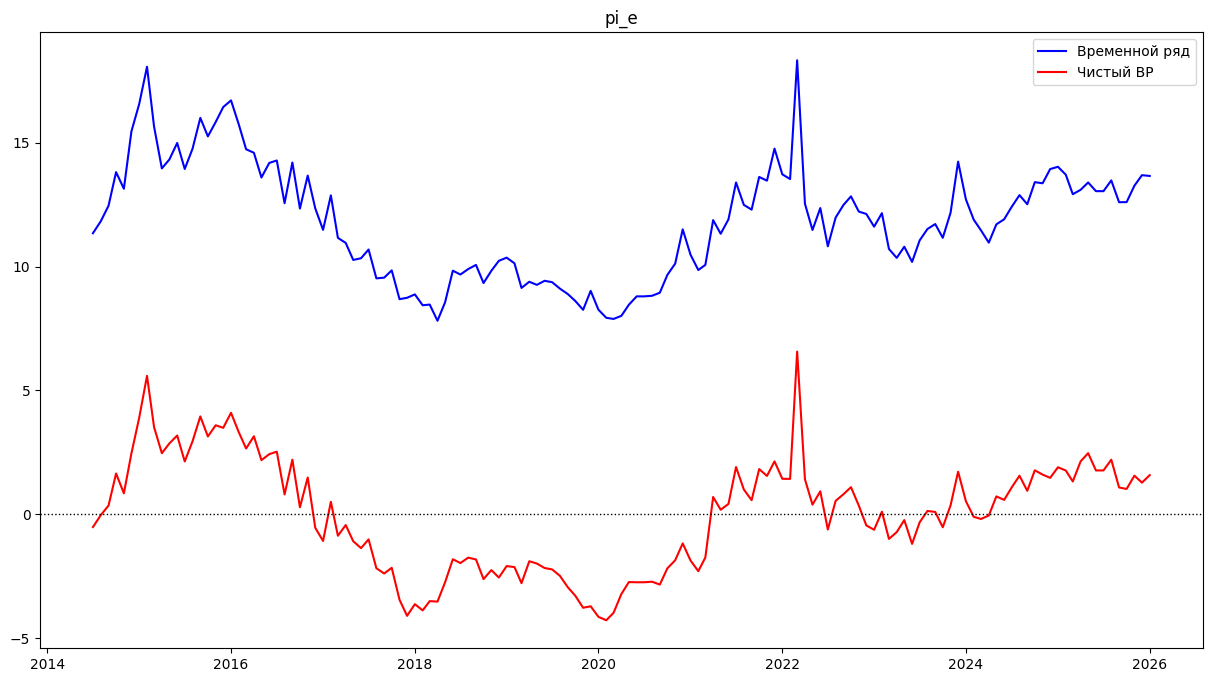

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


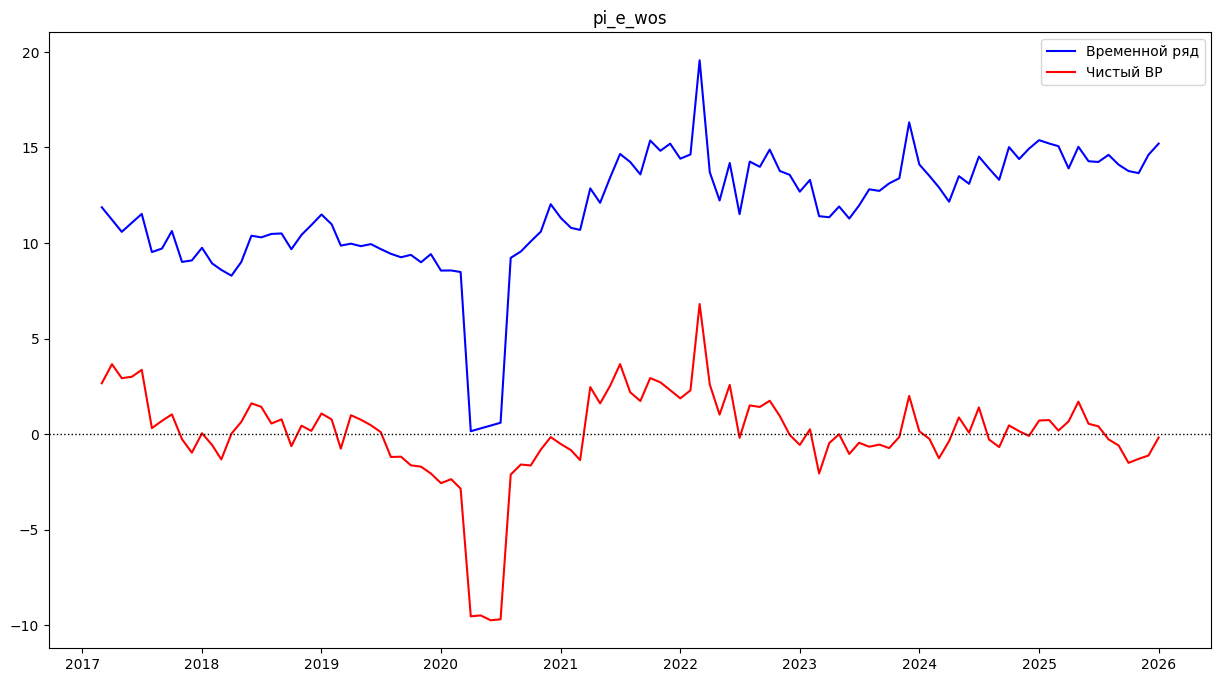

Исходный ряд pi_e_wos оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


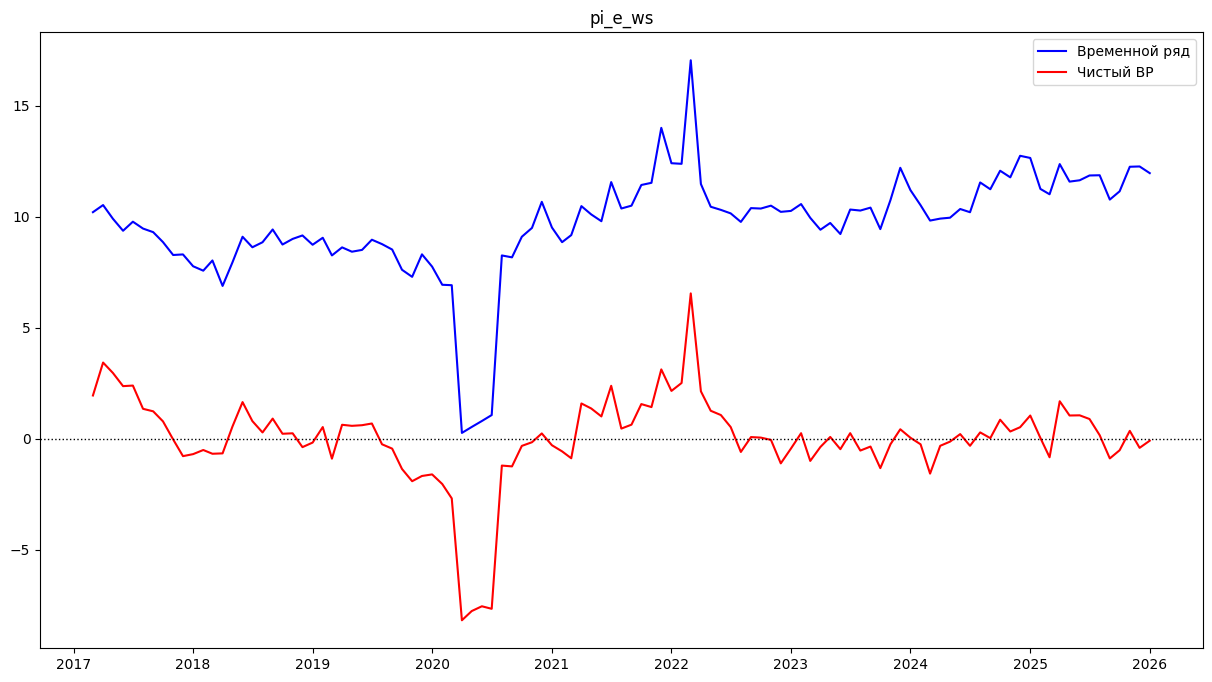

Исходный ряд pi_e_ws оказался стационарным


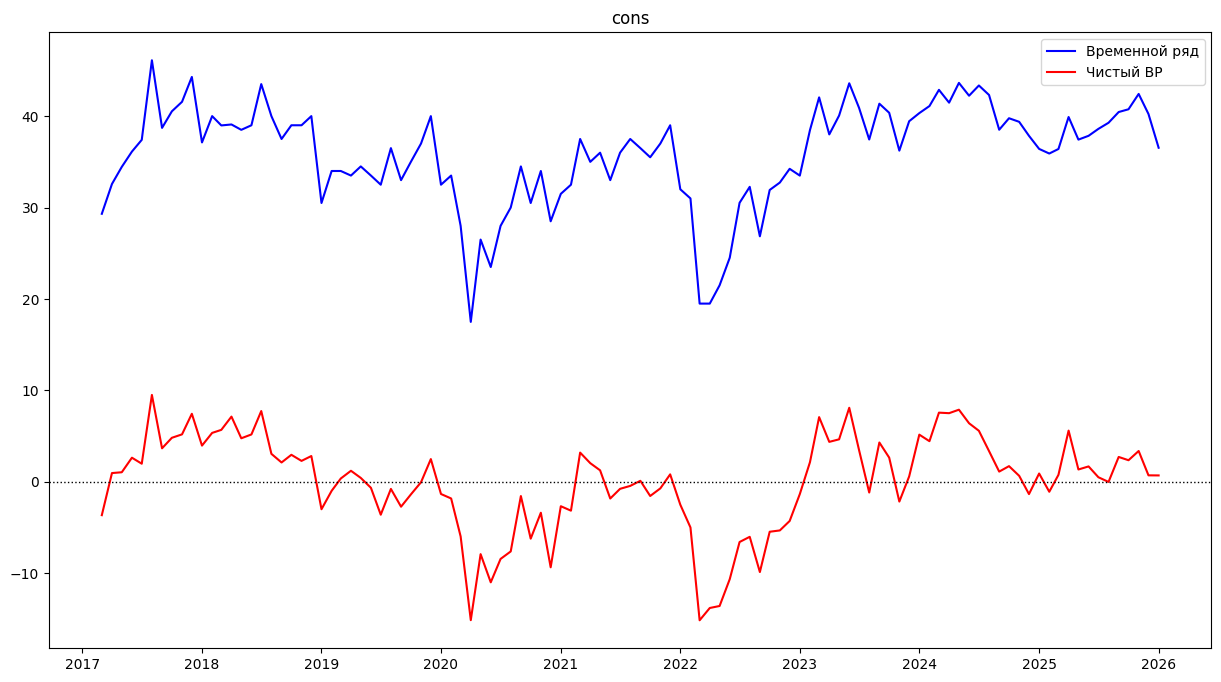

Исходный ряд cons оказался стационарным


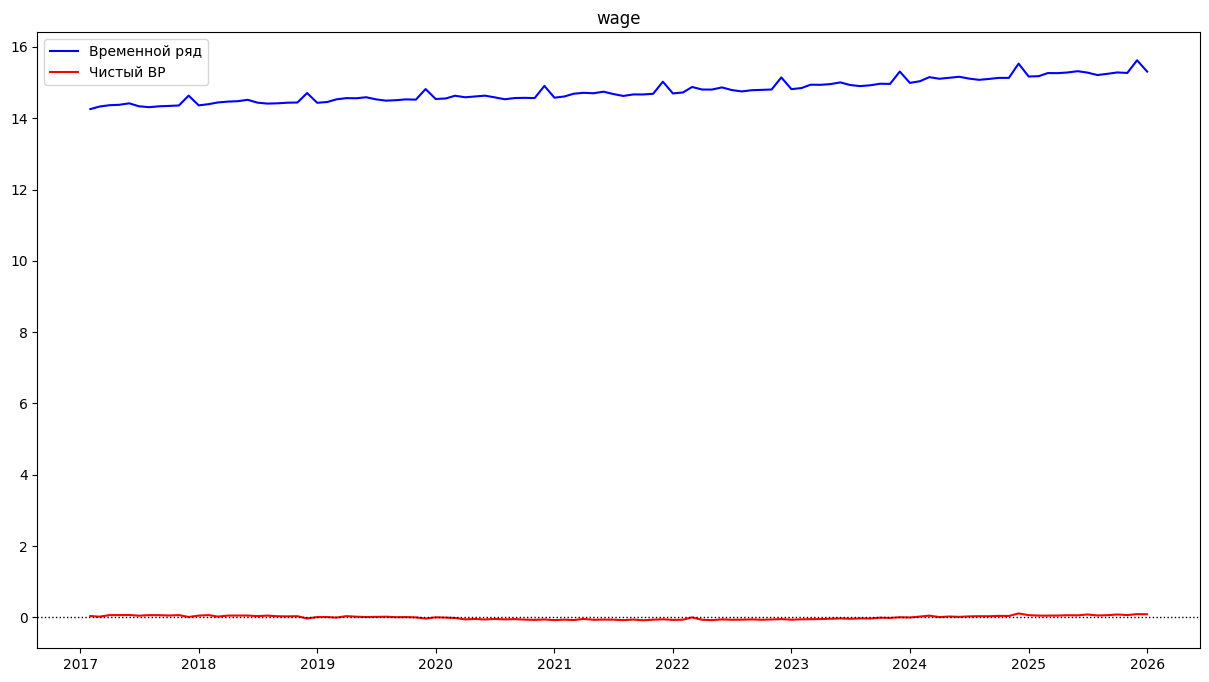

Исходный ряд wage оказался стационарным


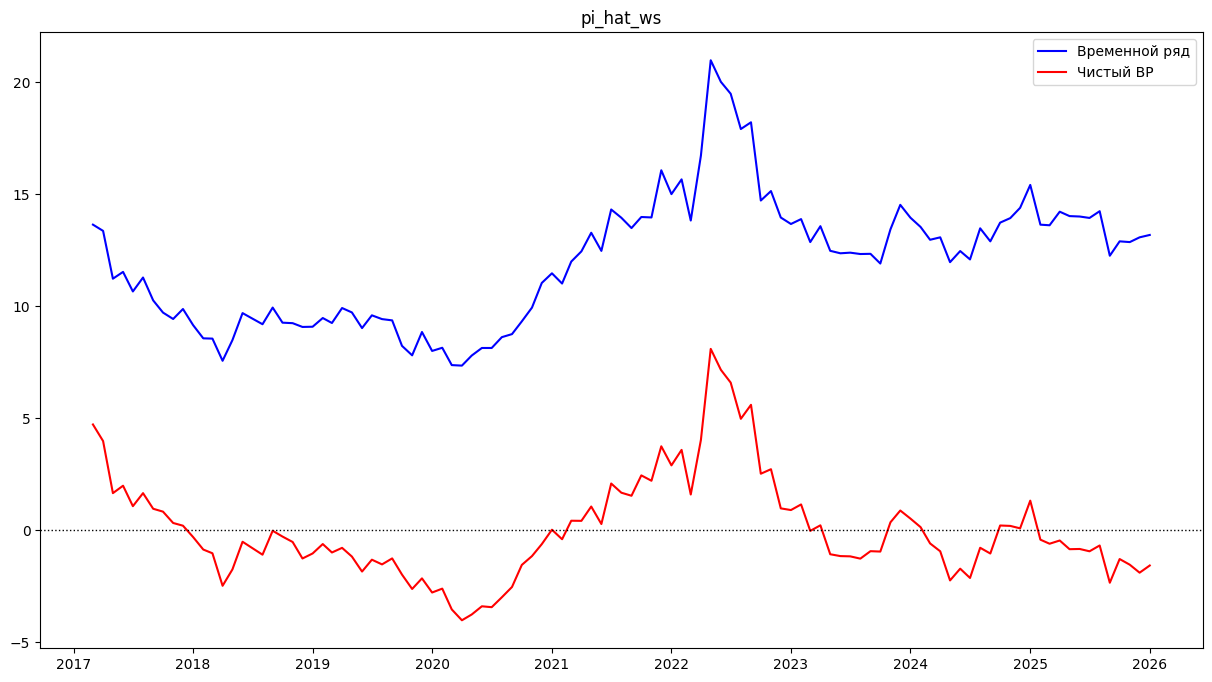

Исходный ряд pi_hat_ws оказался стационарным


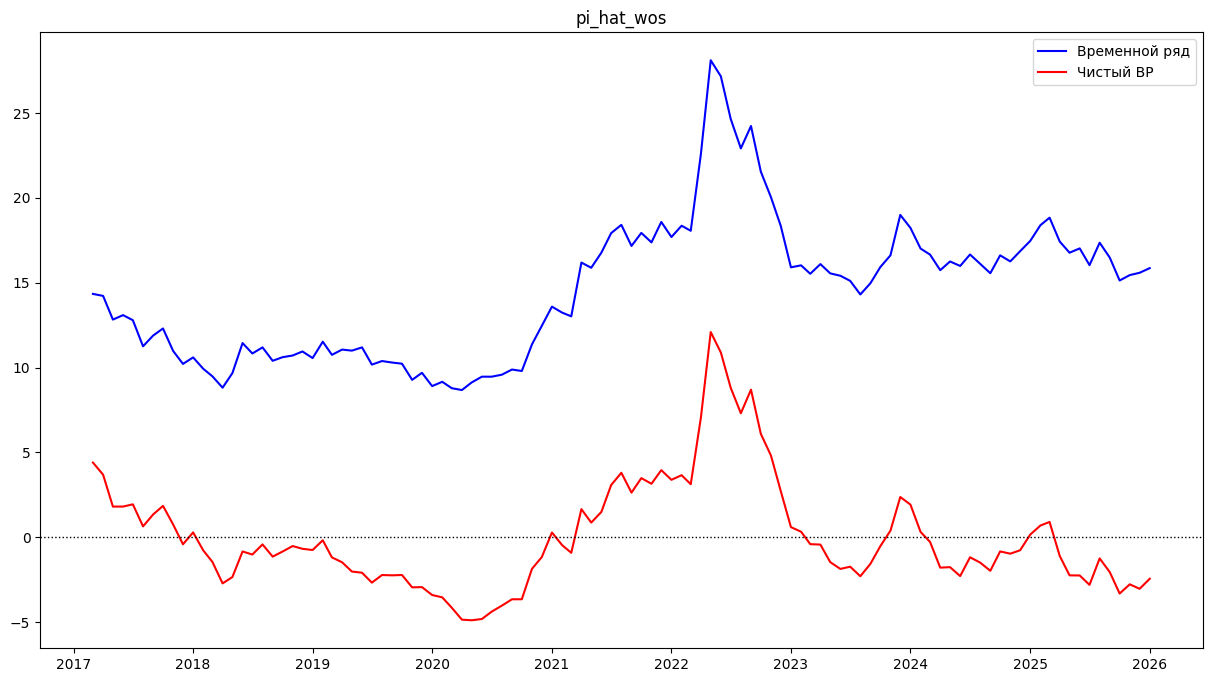

Исходный ряд pi_hat_wos оказался стационарным


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt

import pickle
filename = 'monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)
sd_df = pd.read_excel('data/pi_e/s_d.xlsx')

from structuralvar import Clean, SVAR_KL
var_spec_pie = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['pi_e', 'pi_e_wos', 'pi_e_ws', 'cons', 'wage', 'pi_hat_ws', 'pi_hat_wos']])
var_spec = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['ru_cpi', 'real_ruonia', 'ipi', 'log_deposits_hh', 'log_credits_hh',
                                     'real_brent', 'pi_e', 'pi_e_ws', 'pi_e_wos', 'real_dollar', 'govspend', 'pi_hat_ws', 'pi_hat_wos']])

df, data = var_spec.LOS(use_harmonics=False, only_KPSS = True, hp_filter_map={
                                                                               'ru_cpi': True,
                                                                               'real_rate': False,
                                                                               'm2x_sa_mom': True})
df_pie, data_pie = var_spec_pie.LOS(use_harmonics=False, only_KPSS = True)

covid_start, duration_covid = (data.T.index < dt(2020, 3, 1)).sum(), 5
svo_start, svo_duration = (data.T.index < dt(2022, 2, 1)).sum(), 2

In [6]:
lag = 2

endog_names_pie_general = ['wage', 'cons']
endog_names_pie_special = ['pi_e', 'pi_e_ws', 'pi_e_wos', 'pi_hat_ws', 'pi_hat_wos']
results = {}
for var in endog_names_pie_special:
    df_endog = data_pie.loc[endog_names_pie_general + [var], :].copy()
    df_endog = df_endog.loc[:,df_endog.columns < dt(2020, 4, 1)].copy()   # K×T

    model = SVAR_KL(
        data=df_endog,
        p=lag,
        layout="KL_KxT",
        time_order="chronological",
        add_const=True,
        u_dict = ['шок доходов', 'шок оптимизма', 'шок ОИ'],
        y_dict = ['Объем фонда зарплаты (логарифм)', 'индекс оптимизма', 'инфляционные ожидания']
    ).fit_ols()
    A_hat = model.A_hat
    p = model.p
    K = model.K
    
    unknown_mask = np.array([False, False, True])  

    known_future = data_pie.loc[endog_names_pie_general, :].copy().loc[:,
                        (data_pie.columns > dt(2020, 3, 1)) & (data_pie.columns < dt(2020, 8, 1))]
    res = []
    horizon = known_future.shape[1]
    counter = 0
    future = pd.DataFrame(columns=known_future.columns)
    for i, b in enumerate(unknown_mask):
        
        if not b:
            future.loc[known_future.index.to_list()[i-counter]] = known_future.iloc[i-counter]
        else:
            counter += 1
            future.loc[var] = np.zeros(horizon)    
    for h in range(horizon):
        if h == 0:
            X = model.Z[:, -1]
            
        else:
            
            X = np.hstack([np.array([1]), future.iloc[:, h-1].to_numpy(), X[1:-(K)]])
        y_hat = (A_hat @ X)[unknown_mask]
        future.loc[unknown_mask, future.columns[h]] = y_hat.item()
    results[var] = future.loc[unknown_mask, :]

for var in results:
    data.loc[var,(data.columns > dt(2020, 3, 1)) & (data.columns < dt(2020, 8, 1))] = results[var].to_numpy()

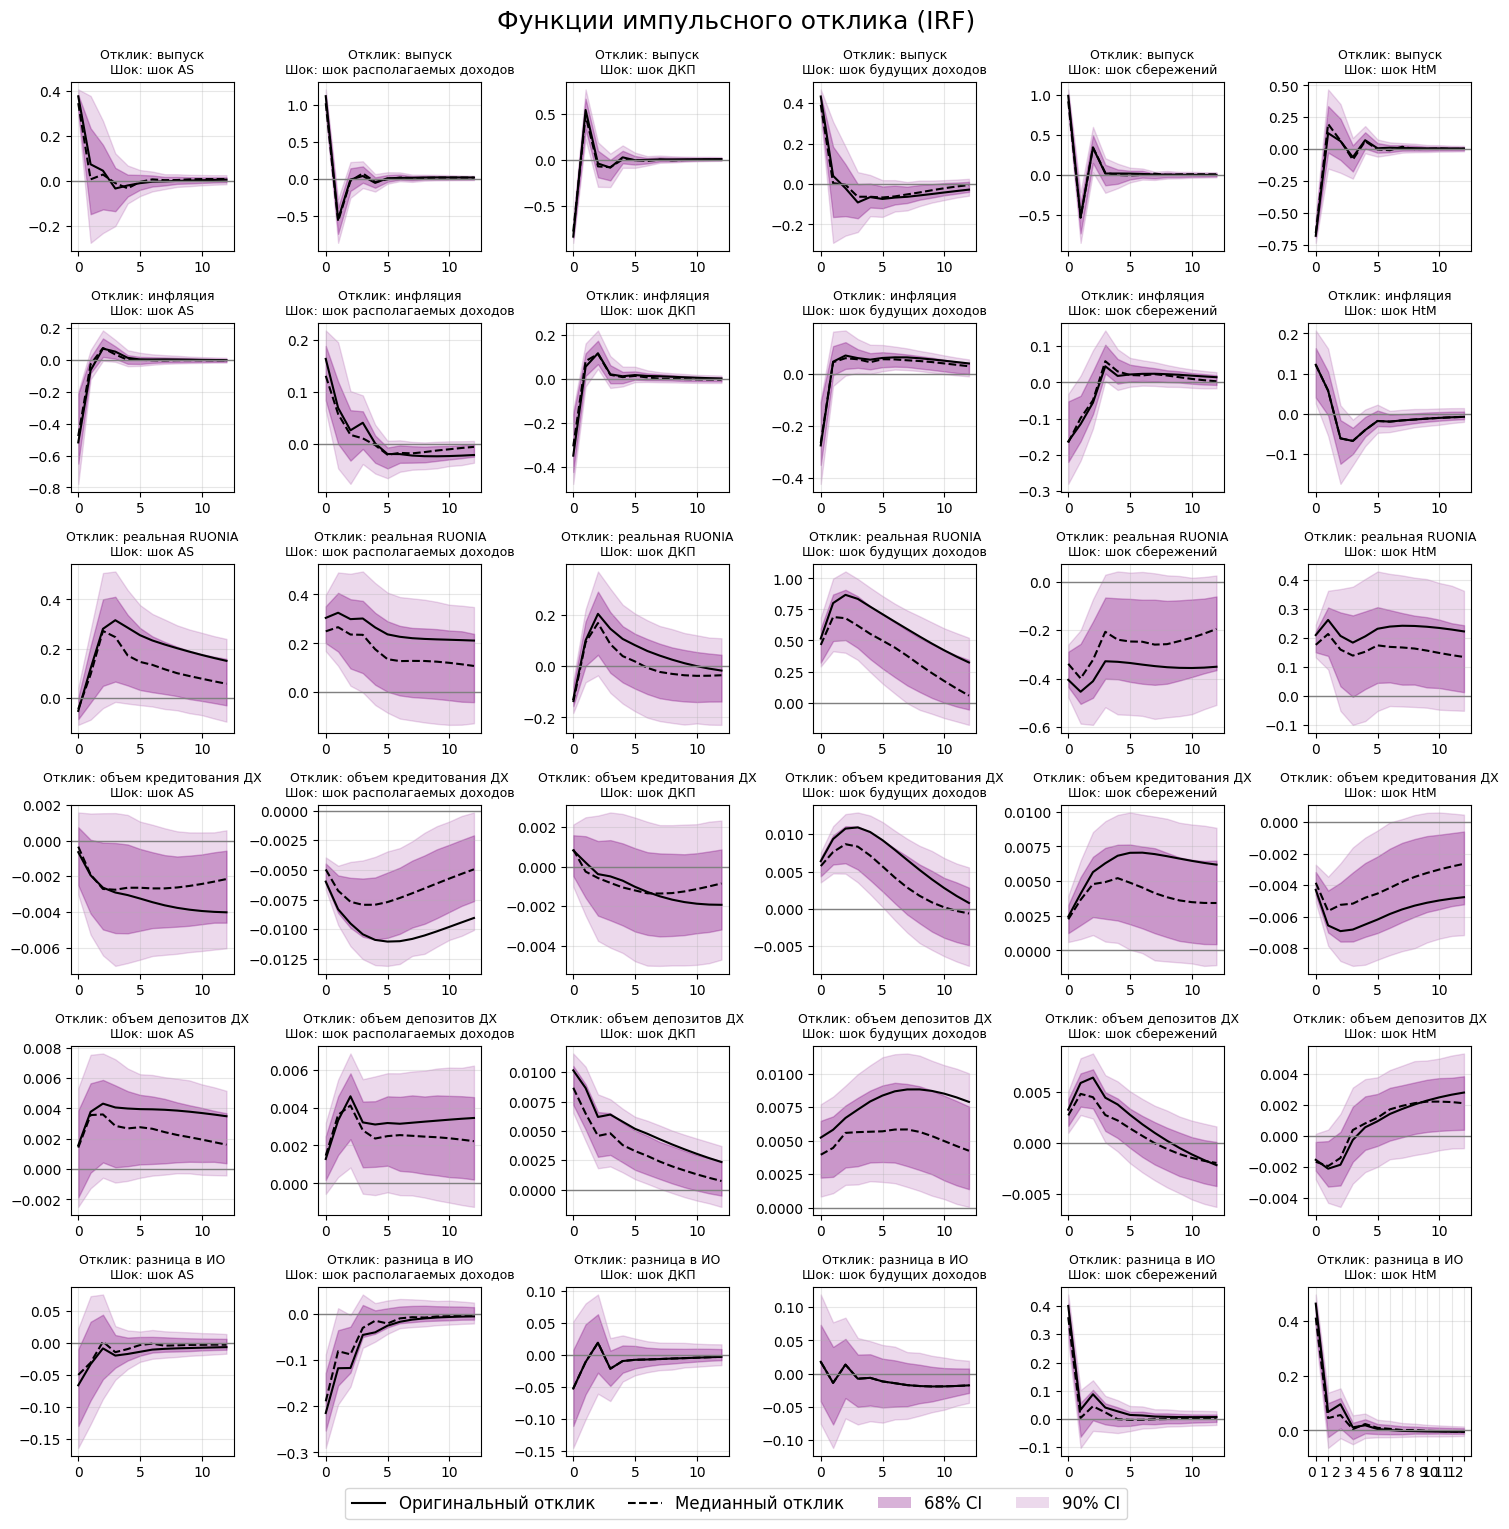

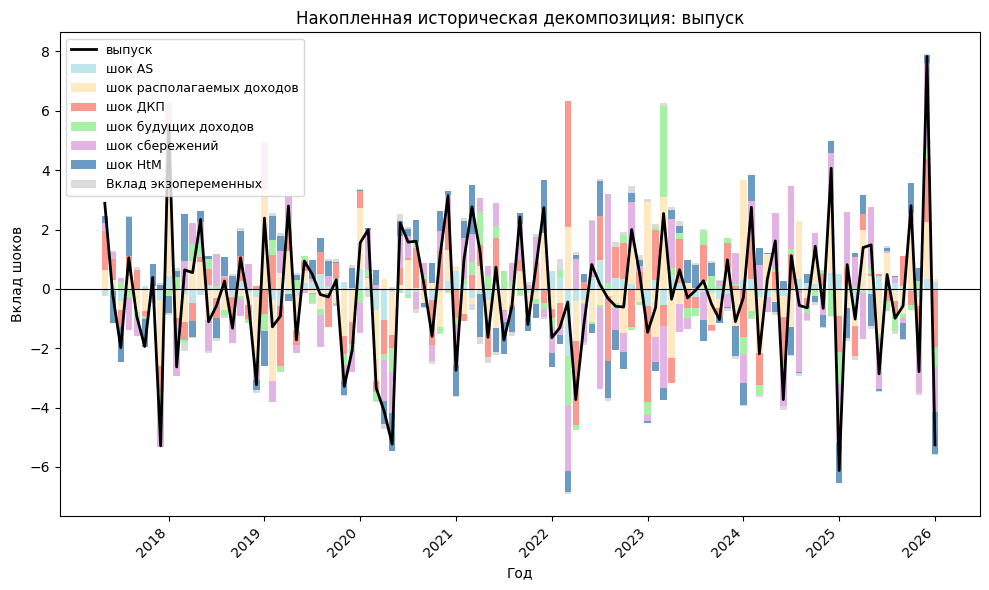

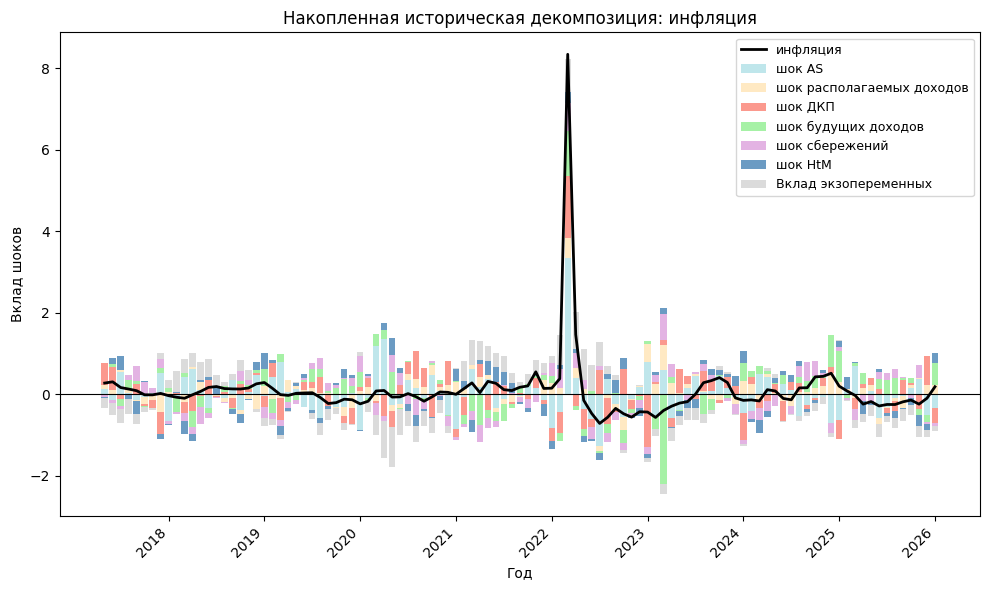

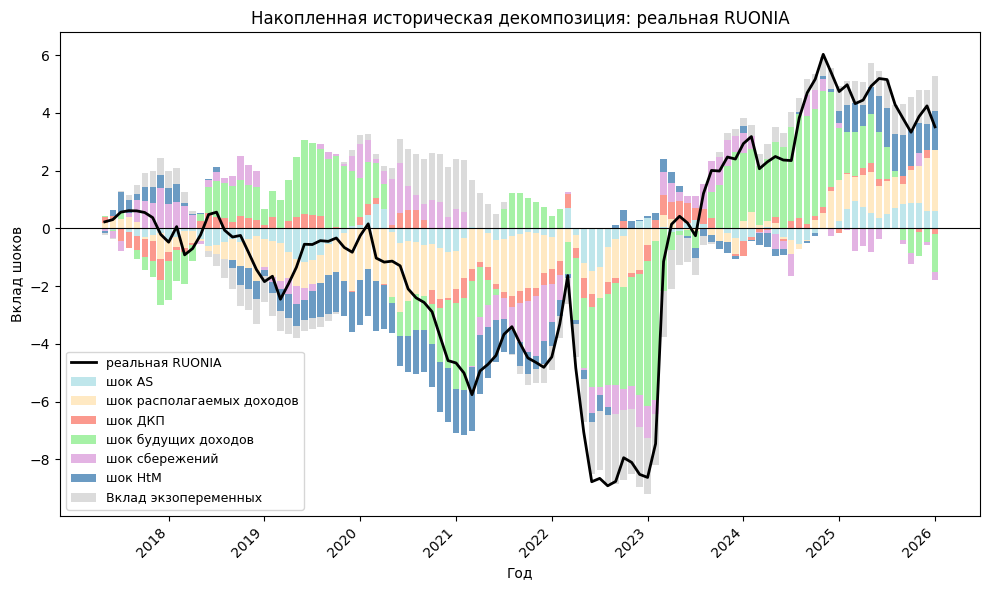

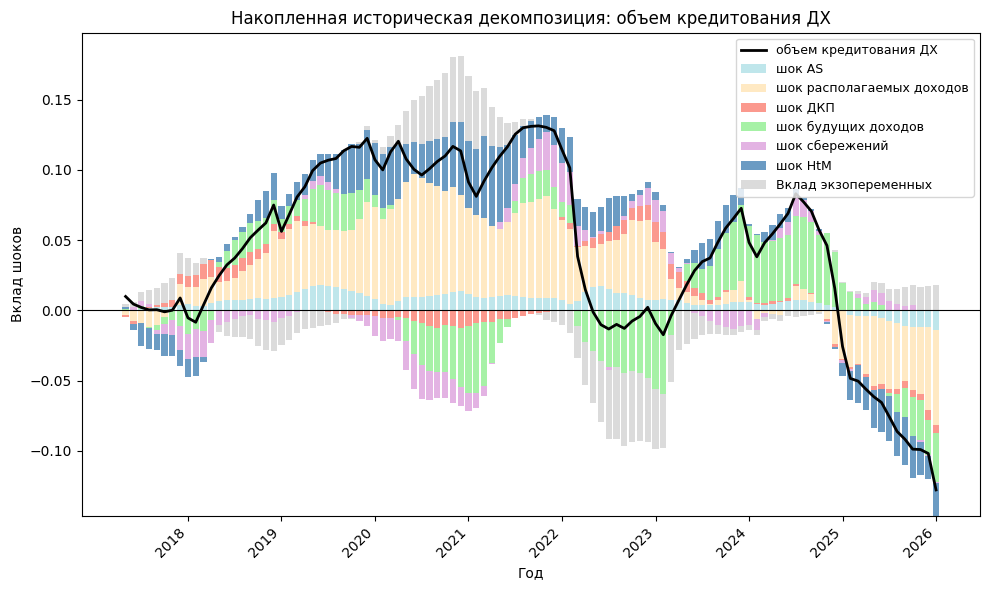

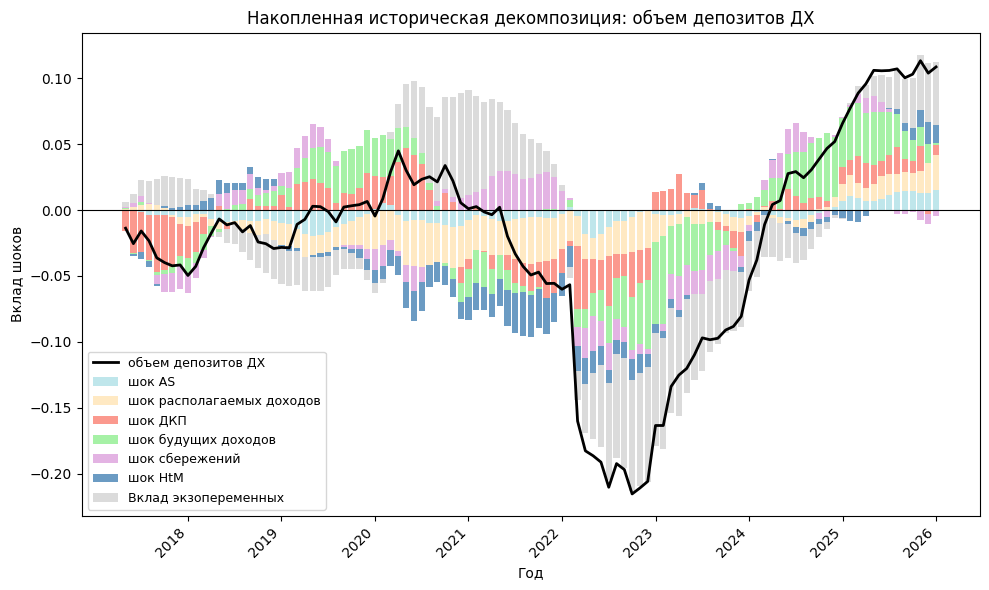

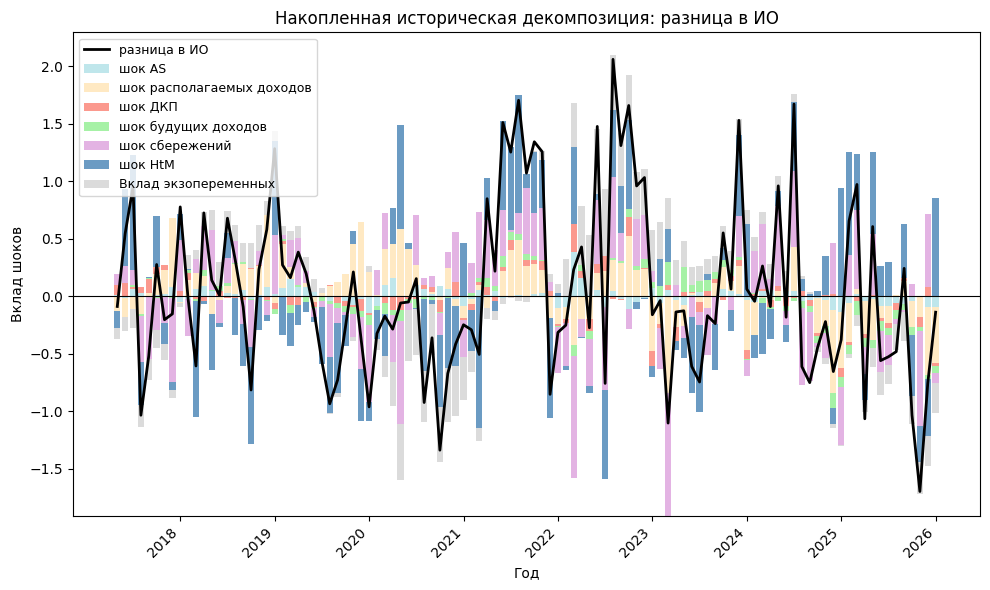

In [21]:
data.loc['pi_e_hete'] = data.loc['pi_e_wos'] - data.loc['pi_e_ws']

short_run_anchor = [
    (0, 0, 1, 0, 1),
    (0, 4, 5, 0, 1),

]
long_run_anchor = [
    (0, 2, 2, 10)
]
short_run_signs = [(0, 1, 2, False, 0, 2),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1.4),
                   (0, 3, 3, True, 0, 1),
                   (0, 0, 0, False, 0, 1),
                   (0, 5, 5, True, 0, 10),
                   (0, 4, 4, True, 0, 20),
                   (0, 2, 3, True, 0, 1),
                   (0, 2, 4, False, 0, 1),
                   (0, 3, 5, False, 0, 10),
                   (0, 2, 1, True, 0, 1),
                   (0, 3, 2, False, 0, 23),
                   (0, 3, 2, False, 1, 20),
                   (0, 3, 2, False, 2, 20),

                   #(0, 4, 3, True, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 5, 2, False, 0, 1),
                   #(1, 5, 5, True, 0, 10),
                   #(0, 5, 4, False, 0, 10),
                   #(0, 5, 3, True, 0, 10)
                   ]
long_run_signs = [
    (0, 3, 5, False, 10),
    (0, 2, 1, True, 10),
    (0, 0, 0, True, 10),
    (0, 0, 1, True,  30),
    #(0, 3, 2, False, 3),
    #(0, 5, 3, True, 3)
]
lag = 2

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'log_credits_hh', 'log_deposits_hh', 'pi_e_hete']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок AS', 'шок располагаемых доходов', 'шок ДКП', 'шок будущих доходов', 'шок сбережений', 'шок HtM'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'объем кредитования ДХ', 'объем депозитов ДХ', 'разница в ИО']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 120
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='purple')


hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)


In [20]:
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
(share_hd_full*100).astype(float).round(1)

,выпуск,инфляция,реальная RUONIA,объем кредитования ДХ,объем депозитов ДХ,разница в ИО
шок AS,6.7,21.4,7.3,6.6,6.0,4.0
шок располагаемых доходов,24.3,9.0,17.5,29.7,13.5,16.4
шок ДКП,19.7,16.3,5.5,4.2,13.4,3.8
шок будущих доходов,7.3,12.1,29.7,19.8,16.9,3.5
шок нормы сбережений,23.4,10.8,10.7,7.3,9.6,25.5
шок HtM,13.9,8.6,12.7,15.6,7.8,28.8
Вклад экзопеременных,2.1,15.0,14.4,13.4,28.8,14.7
Необъяснено шоками,2.7,6.7,2.2,3.3,4.0,3.3


In [31]:
pd.DataFrame(model.Upsilon).round(2).set_axis(list(model.y_dict.values()), axis = 0).set_axis(list(model.u_dict.values()), axis = 1).to_latex()

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & шок AS & шок располагаемых доходов & шок ДКП & шок будущих доходов & шок сбережений & шок HtM \\\\\n\\midrule\nвыпуск & 0.810000 & 1.410000 & -0.200000 & 0.130000 & 0.340000 & -0.010000 \\\\\nинфляция & -0.640000 & -0.370000 & -0.140000 & 0.430000 & 0.290000 & -0.370000 \\\\\nреальная RUONIA & 5.420000 & 9.350000 & 0.000000 & 9.890000 & -12.820000 & 7.750000 \\\\\nобъем кредитования ДХ & -0.170000 & -0.390000 & -0.040000 & -0.010000 & 0.340000 & -0.250000 \\\\\nобъем депозитов ДХ & 0.130000 & 0.180000 & 0.080000 & 0.200000 & -0.140000 & 0.120000 \\\\\nразница в ИО & -0.330000 & -0.840000 & -0.120000 & -0.290000 & 0.920000 & 0.470000 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [29]:
model.u_dict

{'ipi': 'шок AS',
 'ru_cpi': 'шок располагаемых доходов',
 'real_ruonia': 'шок ДКП',
 'log_credits_hh': 'шок будущих доходов',
 'log_deposits_hh': 'шок сбережений',
 'pi_e_hete': 'шок HtM'}

In [18]:
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
(share_hd_full*100).astype(float).round(1)

,выпуск,инфляция,реальная RUONIA,объем кредитования ДХ,объем депозитов ДХ,разница в ИО
шок AS,10.5,14.4,19.8,31.3,17.9,22.6
шок располагаемых доходов,2.9,15.9,8.8,3.0,3.0,8.0
шок ДКП,7.7,24.4,17.1,17.5,22.9,11.8
шок спроса на кредиты,34.5,6.1,14.1,8.5,7.8,2.8
шок спроса на депозиты,30.7,7.0,12.8,4.8,7.1,10.6
шок HtM,8.4,9.4,11.9,19.1,8.5,27.3
Вклад экзопеременных,2.3,15.8,13.3,12.7,28.7,13.8
Необъяснено шоками,3.0,7.1,2.1,3.1,4.0,3.1


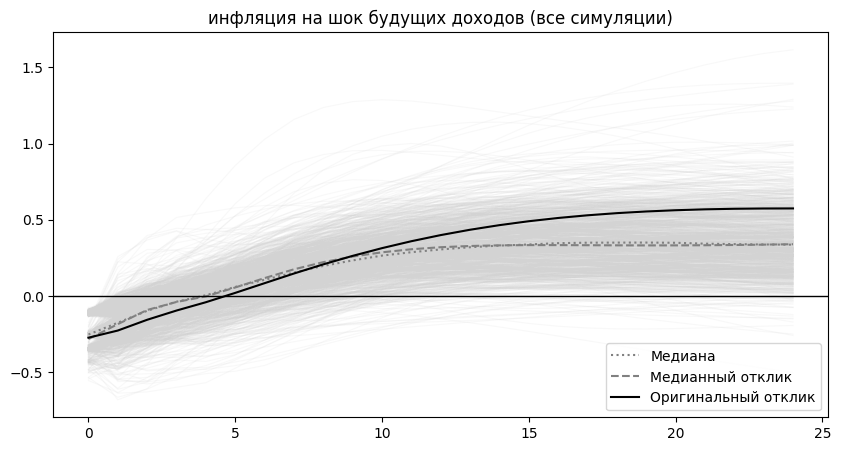

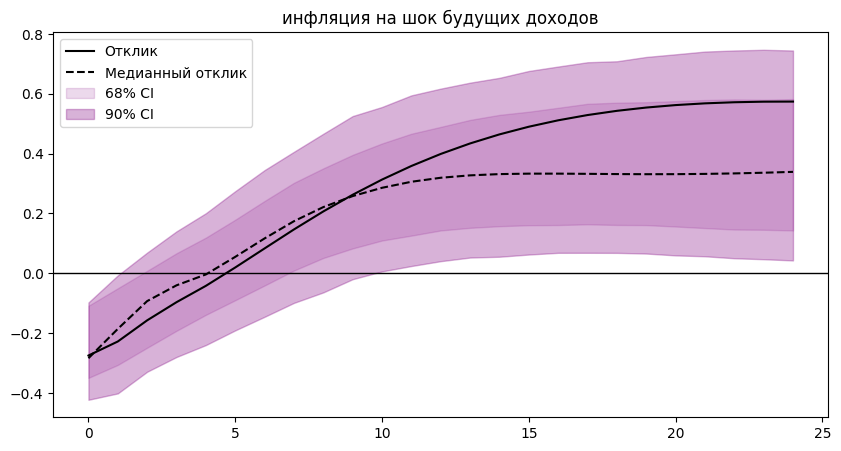

In [28]:
model.plot_single_irf(irf_sims,
                'ru_cpi',
                'шок будущих доходов',
                'purple',
                plot_simulations = True,
                horizon=24,
                cumm = True)